# 📓 Day 5: 机器学习任务攻略 (过拟合与正则化)

> **💡 核心要义**：模型不是万能的，参数太多会变成“死记硬背”的作弊者。防过拟合就是逼模型学“规律”而不是背“答案”。

## 📂 1. 数据集的“三足鼎立”
- **Training Set (训练集)** ➡️ **平时作业**：模型用来计算梯度、更新参数的资料。
- **Validation Set (验证集)** ➡️ **模拟考**：用来**挑选模型结构**和**调超参数**（绝对不能用测试集来调参！）。
- **Testing Set (测试集)** ➡️ **高考**：最终评估，完全未知的真实世界数据。
- *N-fold Cross Validation (N折交叉验证)*：把训练数据切成 N 份轮流当验证集，成绩取平均，防止被特定划分的“简单模拟考”给骗了。

## 📉 2. 诊断：什么是过拟合 (Overfitting)？
- **症状**：Train Loss 持续下降（甚至归零），但 Val/Test Loss 降到一定程度后**不仅不降，反而上升**。
- **病因**：模型太复杂（参数极多），把数据里的“噪声”和“偶然特征”全硬背下来了，画出的拟合曲线扭曲且极端，失去了泛化能力 (Generalization)。

## 🛡️ 3. 四大处方 (如何把模型拉回正轨)

### ① 增加数据 (Data Augmentation) 🌟最根本有效
- **思路**：见多识广就不容易被骗。
- **操作**：收集更多真实数据，或“创造”数据（如：图像左右翻转、随机裁剪、添加噪声）。

### ② 正则化 (Regularization / Weight Decay)
- **思路**：给参数加“紧箍咒”。
- **操作**：在 Loss 函数后加上惩罚项（通常是参数的 $L2$ 范数，即平方和）。
- **效果**：逼迫模型使用更小、更接近 0 的权重参数。参数越小，函数越平滑，对输入的微小扰动越不敏感。

### ③ Dropout (随机失活)
- **思路**：防止神经元互相抱团依赖。
- **操作**：每次 Batch 训练时，随机让 $p\%$ (如 50%) 的神经元“掉线”（断开连接），不参与前向传播和反向更新。
- **效果**：迫使每个神经元独立学习有用特征。测试时全体上阵，等价于训练了无数个瘦弱的子网络并做最终的集成 (Ensemble)。

### ④ 早停 (Early Stopping)
- **思路**：见好就收。
- **操作**：训练时死盯 Validation Loss，一旦发现它见底并开始连续反弹，立刻“踩刹车”停止训练。
- **效果**：直接保存 Validation 表现最好的那一轮 (Epoch) 的参数。



# 📓  数学: 条件概率与贝叶斯定理

> **💡 核心要义**：贝叶斯定理不仅仅是一个数学公式，更是一种“用新证据来不断更新旧认知”的世界观。在机器学习中，它是极其强大的概率分类工具。

## 🎲 1. 条件概率 (Conditional Probability)
- **定义**：在事件 $B$ 已经发生的“缩小宇宙”里，事件 $A$ 发生的概率。
- **公式**：$P(A|B) = \frac{P(A \cap B)}{P(B)}$
- **直觉解释**：把 $B$ 当作全新的总样本空间（分母），看 $A$ 在这个新空间中占多大比例（分子）。

## 🧠 2. 贝叶斯定理 (Bayes' Theorem) 🌟核心
- **推导来源**：因为 $P(A \cap B) = P(A|B)P(B) = P(B|A)P(A)$，左右一移项就得到了贝叶斯公式。
- **核心公式**：
  $$P(A|B) = \frac{P(B|A) \cdot P(A)}{P(B)}$$
- **四大核心部件**：
  1. **$P(A)$ 先验概率 (Prior)**：在没看到任何证据前，你的初始预估。（例：一封邮件是垃圾邮件的基础概率）。
  2. **$P(B)$ 边缘概率/证据 (Evidence)**：不论 $A$ 真假，观察到证据 $B$ 发生的总概率。（例：所有邮件中出现“中奖”这个词的概率）。
  3. **$P(B|A)$ 似然 (Likelihood)**：如果 $A$ 确实是真的，那出现证据 $B$ 的概率有多大？（例：如果是垃圾邮件，它里面写着“中奖”的概率）。
  4. **$P(A|B)$ 后验概率 (Posterior)**：【我们真正要求的】看到了证据 $B$ 之后，修正更新后的 $A$ 发生概率。（例：看到邮件写了“中奖”，它真的是垃圾邮件的概率）。

## 🚀 3. 工程落地：朴素贝叶斯 (Naive Bayes)
- **应用场景**：垃圾邮件过滤 (Spam Filter)、情感分析等文本分类任务。
- **计算逻辑**：
  $$P(垃圾 | 含"免费"和"链接") \propto P("免费"|垃圾) \cdot P("链接"|垃圾) \cdot P(垃圾)$$
- **为什么叫“朴素 (Naive)”？**
  - 因为它做了一个非常“天真粗暴”的假设：**假设所有特征相互独立**。
  - 真实世界里，“免费”和“链接”经常结伴出现（不独立）。但朴素贝叶斯为了计算方便，假装它们互不影响，直接将各自的概率相乘。
  - **奇妙的现实**：虽然理论假设很离谱，但在实际的机器学习工程中，它的分类准确率出奇地高，而且计算速度极快（只需要查表和乘法）。


In [10]:
import math
import numpy as np 
import torch
from torch import nn
from d2l import torch as d2l

max_degree = 20
n_train, n_test = 100, 100
true_w = np.zeros(max_degree)
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)
labels = np.dot(poly_features, true_w)
labels += np.random.normal(scale=0.1, size=labels.shape)

true_w, features, poly_features, labels = [torch.tensor(x, dtype=torch.float32)
 for x in [true_w, features, poly_features, labels]]

features[:2], poly_features[:2, :], labels[:2]

(tensor([[-0.3074],
         [-0.9433]]),
 tensor([[ 1.0000e+00, -3.0736e-01,  4.7235e-02, -4.8393e-03,  3.7185e-04,
          -2.2858e-05,  1.1710e-06, -5.1415e-08,  1.9753e-09, -6.7460e-11,
           2.0734e-12, -5.7935e-14,  1.4839e-15, -3.5084e-17,  7.7024e-19,
          -1.5783e-20,  3.0318e-22, -5.4815e-24,  9.3600e-26, -1.5141e-27],
         [ 1.0000e+00, -9.4329e-01,  4.4490e-01, -1.3989e-01,  3.2990e-02,
          -6.2238e-03,  9.7848e-04, -1.3186e-04,  1.5547e-05, -1.6295e-06,
           1.5371e-07, -1.3182e-08,  1.0362e-09, -7.5186e-11,  5.0659e-12,
          -3.1857e-13,  1.8782e-14, -1.0422e-15,  5.4615e-17, -2.7115e-18]]),
 tensor([4.5020, 1.6002]))

weight: [[ 5.0064354e+00  1.2365434e+00 -3.3832586e+00  5.3191428e+00
  -2.4373049e-03  1.0214180e+00  6.0893245e-02  7.8974381e-02
  -1.9366232e-01  8.5350230e-02 -7.3731378e-02  5.8809780e-02
   4.0413074e-02  1.4320940e-01  1.6448422e-01 -8.5334904e-02
  -4.8947793e-02  8.9631036e-02  8.4517829e-02 -1.6661735e-01]]


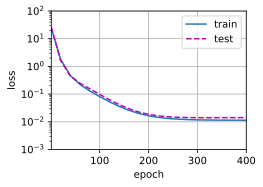

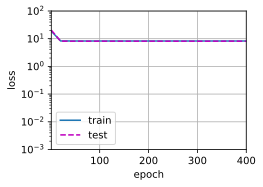

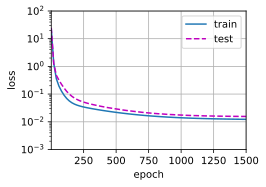

In [11]:
def evaluate_loss(net, data_iter, loss):  #@save
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2)  # 损失的总和,样本数量
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel())
    return metric[0] / metric[1]

def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]
    # 不设置偏置，因为我们已经在多项式中实现了它
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)),
                                batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)),
                               batch_size, is_train=False)
    trainer = torch.optim.SGD(net.parameters(), lr=0.01)
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])
    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

# 从多项式特征中选择前4个维度，即1,x,x^2/2!,x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4],
      labels[:n_train], labels[n_train:])

# 从多项式特征中选择前2个维度，即1和x
train(poly_features[:n_train, :2], poly_features[n_train:, :2],
      labels[:n_train], labels[n_train:])

# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :],
      labels[:n_train], labels[n_train:], num_epochs=1500)

In [12]:
# dropout 从0实现
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=True)

def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())


w的L2范数是： 14.1981840133667


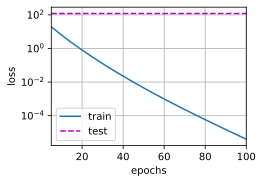

In [13]:
# 忽略正则化直接训练
train(lambd=0)

w的L2范数是： 0.37013086676597595


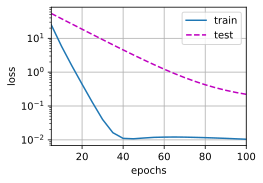

In [14]:
# 使用权重衰减
train(lambd=3)

In [15]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd},
        {"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())

w的L2范数： 13.928524017333984


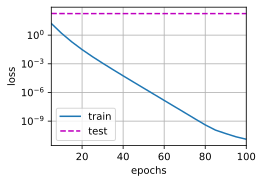

In [16]:
train_concise(0)

w的L2范数： 0.3304591476917267


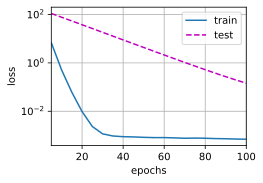

In [17]:
train_concise(3)

In [18]:
# 从0实现暂退法
import torch
from torch import nn
from d2l import torch as d2l

def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1:
        return torch.zeros_like(X)
    if dropout == 0:
        return X
    mask = (torch.rand(X.shape) > dropout).float()
    return mask * X / (1.0 - dropout)

X = torch.arange(16, dtype=torch.float32).reshape((2, 8))
print(X)
print(dropout_layer(X, 0.))
print(dropout_layer(X, 0.5))
print(dropout_layer(X, 1.))

tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
tensor([[ 0.,  0.,  4.,  0.,  0., 10.,  0.,  0.],
        [ 0.,  0., 20., 22., 24., 26.,  0., 30.]])
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


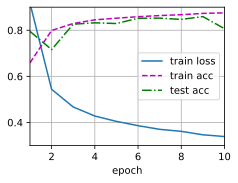

In [19]:
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256
dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training = True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training
        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        if self.training == True:
            H1 = dropout_layer(H1, dropout1)
        H2 = self.relu(self.lin2(H1))
        if self.training == True:
            H2 = dropout_layer(H2, dropout2)
        out = self.lin3(H2)
        return out

net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)

num_epochs, lr, batch_size = 10, 0.5, 256
loss = nn.CrossEntropyLoss(reduction='none')
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)
trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)

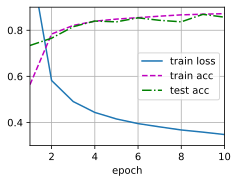

In [20]:
# 简洁实现
net = nn.Sequential(nn.Flatten(),
                    nn.Linear(784, 256),
                    nn.ReLU(),
                    nn.Dropout(dropout1),
                    nn.Linear(256, 256),
                    nn.ReLU(),
                    nn.Dropout(dropout2),
                    nn.Linear(256, 10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net.apply(init_weights)

trainer = torch.optim.SGD(net.parameters(), lr=lr)
d2l.train_ch3(net, train_iter, test_iter, loss, num_epochs, trainer)